<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

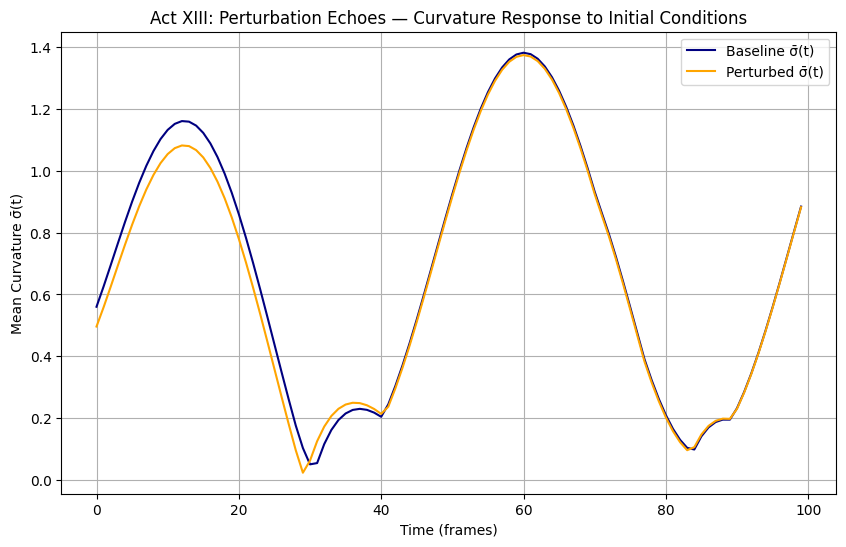

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------
# Step 1: Build Network
# -------------------------------
def build_boundary_bulk_network(boundary_size=8, bulk_size=32):
    G = nx.Graph()
    boundary_nodes = [f"B{i}" for i in range(boundary_size)]
    bulk_nodes = [f"U{i}" for i in range(bulk_size)]

    G.add_nodes_from(boundary_nodes, region='boundary')
    G.add_nodes_from(bulk_nodes, region='bulk')

    for b in boundary_nodes:
        connections = np.random.choice(bulk_nodes, size=4, replace=False)
        for u in connections:
            G.add_edge(b, u)

    for i in range(bulk_size):
        for j in range(i + 1, bulk_size):
            if np.random.rand() < 0.1:
                G.add_edge(f"U{i}", f"U{j}")

    return G

# -------------------------------
# Step 2: Initialize δ and κ
# -------------------------------
def initialize_weights(G, delta_init=0.5, kappa_init=0.5):
    for node in G.nodes:
        region = G.nodes[node]['region']
        G.nodes[node]['delta'] = delta_init if region == 'boundary' else 0.0
        G.nodes[node]['kappa'] = kappa_init if region == 'bulk' else 0.0

# -------------------------------
# Step 3: Recursive Update
# -------------------------------
def update_weights(G, t, delta_base=1.0, kappa_base=1.0, alpha=0.9, beta=0.9, gamma=0.1):
    delta_t = delta_base * np.sin(2 * np.pi * t / 50)
    kappa_t = kappa_base * np.cos(2 * np.pi * t / 50)
    curvature = compute_curvature(G)

    for node in G.nodes:
        region = G.nodes[node]['region']
        prev_delta = G.nodes[node]['delta']
        prev_kappa = G.nodes[node]['kappa']
        sigma = curvature[node]

        if region == 'boundary':
            G.nodes[node]['delta'] = alpha * prev_delta + (1 - alpha) * delta_t - gamma * sigma
            G.nodes[node]['kappa'] = 0.0
        else:
            G.nodes[node]['kappa'] = beta * prev_kappa + (1 - beta) * kappa_t + gamma * sigma
            G.nodes[node]['delta'] = 0.0

# -------------------------------
# Step 4: Curvature
# -------------------------------
def compute_curvature(G):
    return {node: np.abs(G.nodes[node]['delta'] - G.nodes[node]['kappa']) for node in G.nodes}

# -------------------------------
# Step 5: Run Simulation
# -------------------------------
def run_curvature_simulation(delta_init, kappa_init, frames=100):
    G = build_boundary_bulk_network()
    initialize_weights(G, delta_init, kappa_init)

    sigma_means = []

    for t in range(frames):
        update_weights(G, t)
        sigma_vals = list(compute_curvature(G).values())
        sigma_means.append(np.mean(sigma_vals))

    return sigma_means

# -------------------------------
# Step 6: Compare Perturbations
# -------------------------------
baseline_sigma = run_curvature_simulation(0.5, 0.5)
perturbed_sigma = run_curvature_simulation(0.6, 0.4)

plt.figure(figsize=(10, 6))
plt.plot(baseline_sigma, label='Baseline σ̄(t)', color='navy')
plt.plot(perturbed_sigma, label='Perturbed σ̄(t)', color='orange')
plt.title("Act XIII: Perturbation Echoes — Curvature Response to Initial Conditions")
plt.xlabel("Time (frames)")
plt.ylabel("Mean Curvature σ̄(t)")
plt.legend()
plt.grid(True)
plt.show()
